
# Hotel Booking Analysis - Assignment Notebook

This notebook covers:
- ETL / data cleaning
- EDA / visual analysis
- Clustering / customer-demand segments
- Forecasting / monthly booking demand



## Importing the libraries

In [1]:
# Core libraries
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

RANDOM_STATE = 42
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Loading the Dataset

In [2]:
# Load data
local_path = Path('hotel_bookings.csv')
backup_url = 'https://raw.githubusercontent.com/Sid-darthvader/DoWhy-The-Causal-Story-Behind-Hotel-Booking-Cancellations/master/hotel_bookings.csv'

if local_path.exists():
    df = pd.read_csv(local_path)
    print(f'Loaded local file: {local_path.resolve()}')
else:
    print('Local CSV not found. Trying public backup URL...')
    try:
        df = pd.read_csv(backup_url)
        print('Loaded data from backup URL.')
    except Exception as e:
        raise FileNotFoundError(
            'Could not load the dataset. Please download hotel_bookings.csv from Kaggle and place it next to this notebook.'
        ) from e

Local CSV not found. Trying public backup URL...
Loaded data from backup URL.


In [3]:
df.shape

(119390, 32)

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [6]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

## 2. Data Preprocessing, Data Cleaning and Feature Engineering

In [7]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [8]:
df_clean = df

In [9]:
df_clean['is_canceled'] = df_clean['is_canceled'].astype('category')   #change the data type of is_cancelled variable


In [10]:
df_clean['arrival_date_YMD'] = pd.to_datetime(
    df_clean['arrival_date_year'].astype(str) + '-' +
    df_clean['arrival_date_month'].astype(str) + '-' +
    df_clean['arrival_date_day_of_month'].astype(str),
    errors='coerce'
)        # keeping day,month,year together in a another variable for forecasting

In [11]:
df_clean.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date_YMD
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01


In [12]:
df_clean.dtypes

hotel                                     object
is_canceled                             category
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

#### Data Cleaning - Missing Values Treatment

In [13]:
df_clean.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [14]:
df_clean['children'] = df_clean['children'].fillna(df['children'].mean())    #replacing missing values in children variable with mean.
df_clean['country'] = df_clean['country'].fillna('Unknown')       #replacing country variable missing values with unknown value

In [15]:
df_clean['agent'] = df_clean['agent'].fillna(0)     #Replacing missing values of agent variable with 0

In [16]:
df_clean['company'] = df_clean['company'].fillna(0)    #Replacing missing values of company variable with 0

#### Data Cleaning - Checking impossible bookings with zero guest counts

In [17]:
if {'adults', 'children', 'babies'}.issubset(df_clean.columns):     # Remove impossible bookings with zero guests
    total_people = df_clean['adults'] + df_clean['children'] + df_clean['babies']
    df_clean = df_clean.loc[total_people > 0].copy()

In [18]:
df.shape

(119390, 33)

#### Data Cleaning - Checking for duplicates

In [19]:
duplicates = df_clean[df_clean.duplicated()]    # Removing Duplicates
print("Number of duplicate rows:", duplicates.shape[0])
display(duplicates)

Number of duplicate rows: 31980


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date_YMD
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,0.0,0,Transient,98.00,0,1,Check-Out,2015-07-03,2015-07-01
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,250.0,0.0,0,Transient,84.67,0,1,Check-Out,2015-07-07,2015-07-01
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,250.0,0.0,0,Transient,137.00,0,1,Check-Out,2015-07-07,2015-07-02
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,240.0,0.0,0,Transient,97.00,0,0,Canceled,2015-07-01,2015-07-05
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,240.0,0.0,0,Transient,109.80,0,3,Check-Out,2015-07-08,2015-07-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,...,9.0,0.0,0,Transient,126.00,0,2,Check-Out,2017-09-03,2017-08-31
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,9.0,0.0,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03,2017-08-31
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,9.0,0.0,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03,2017-08-31
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,9.0,0.0,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03,2017-08-31


In [20]:
# Remove duplicate rows
before_dupes = len(df_clean)
df_clean = df_clean.drop_duplicates().copy()
print('Duplicates removed:', before_dupes - len(df_clean))

Duplicates removed: 31980


In [21]:
df_clean.shape

(87230, 33)

#### Feature Engineering

- Changing the 'month' variable

In [22]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
month_map = {m: i+1 for i, m in enumerate(month_order)}
month_map

{'January': 1,
 'February': 2,
 'March': 3,
 'April': 4,
 'May': 5,
 'June': 6,
 'July': 7,
 'August': 8,
 'September': 9,
 'October': 10,
 'November': 11,
 'December': 12}

In [23]:
df_clean['arrival_month_num'] = df_clean['arrival_date_month'].map(month_map)

- Creation of new variables

In [24]:
df_clean['total_nights'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']
df_clean['total_guests'] = df_clean['adults'] + df_clean['children'] + df_clean['babies']
df_clean['is_family'] = ((df_clean['children'] + df_clean['babies']) > 0).astype(int)
df_clean['revenue_proxy'] = np.where(df_clean['is_canceled'] == 0, df_clean['adr'] * df_clean['total_nights'], 0)
df_clean['different_room_assigned'] = (df_clean['reserved_room_type'] != df_clean['assigned_room_type']).astype(int)

In [25]:
df_clean.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'arrival_date_YMD',
       'arrival_month_num', 'total_nights', 'total_guests', 'is_family',
       'revenue_proxy', 'different_room_assigned'],
      dtype='object')

#### Checking for outliers

In [26]:
# Mild outlier capping for adr using IQR
q1 = df_clean['adr'].quantile(0.25)
q3 = df_clean['adr'].quantile(0.75)
iqr = q3 - q1
lower = max(0, q1 - 1.5 * iqr)
upper = q3 + 1.5 * iqr
df_clean['adr_capped'] = df_clean['adr'].clip(lower=lower, upper=upper)

In [27]:
# Mild outlier capping for adr using IQR
q1 = df_clean['lead_time'].quantile(0.25)
q3 = df_clean['lead_time'].quantile(0.75)
iqr = q3 - q1
lower = max(0, q1 - 1.5 * iqr)
upper = q3 + 1.5 * iqr
df_clean['lead_time_capped'] = df_clean['lead_time'].clip(lower=lower, upper=upper)

In [28]:
df_clean.shape

(87230, 41)

In [29]:
df_clean.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'arrival_date_YMD',
       'arrival_month_num', 'total_nights', 'total_guests', 'is_family',
       'revenue_proxy', 'different_room_assigned', 'adr_capped',
       'lead_time_capped'],
      dtype='object')

In [30]:
core_cols = [
    'hotel',
    'is_canceled',
    'lead_time',
    'adults',
    'children',
    'babies',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'reserved_room_type',
    'assigned_room_type',
    'booking_changes',
    'deposit_type',
    'agent',
    'days_in_waiting_list',
    'customer_type',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'lead_time_capped'
]

In [31]:
engineered_cols = [
    'arrival_date_YMD',
    'arrival_month_num',
    'total_nights',
    'total_guests',
    'is_family',
    'revenue_proxy',
    'different_room_assigned',
    'adr_capped'
]

In [32]:
final_cols = core_cols + engineered_cols

df_final_cleaned = df_clean[final_cols].copy()

print("Final dataset shape:", df_final_cleaned.shape)

Final dataset shape: (87230, 31)


###### Removed variables : 'arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month',  'arrival_date_week_number',  'reservation_status',   'reservation_status_date',  'company',  'adr'

In [33]:
df_final_cleaned.head()

,hotel,is_canceled,lead_time,adults,children,babies,meal,country,market_segment,distribution_channel,...,total_of_special_requests,lead_time_capped,arrival_date_YMD,arrival_month_num,total_nights,total_guests,is_family,revenue_proxy,different_room_assigned,adr_capped
0,Resort Hotel,0,342,2,0.0,0,BB,PRT,Direct,Direct,...,0,296,2015-07-01,7,0,2.0,0,0.0,0,0.0
1,Resort Hotel,0,737,2,0.0,0,BB,PRT,Direct,Direct,...,0,296,2015-07-01,7,0,2.0,0,0.0,0,0.0
2,Resort Hotel,0,7,1,0.0,0,BB,GBR,Direct,Direct,...,0,7,2015-07-01,7,1,1.0,0,75.0,1,75.0
3,Resort Hotel,0,13,1,0.0,0,BB,GBR,Corporate,Corporate,...,0,13,2015-07-01,7,1,1.0,0,75.0,0,75.0
4,Resort Hotel,0,14,2,0.0,0,BB,GBR,Online TA,TA/TO,...,1,14,2015-07-01,7,2,2.0,0,196.0,0,98.0


In [34]:
# Save cleaned data
processed_dir = Path('df_final_cleaned')
processed_dir.mkdir(exist_ok=True)
clean_path = processed_dir / 'hotel_bookings_clean.csv'
df_clean.to_csv(clean_path, index=False)
print(f'Saved cleaned dataset to: {clean_path.resolve()}')


Saved cleaned dataset to: C:\Users\ranpa\Desktop\MSc in DS\Principles of DS\Courseworks\Individual Portfolio & Group\Group Coursework\df_final_cleaned\hotel_bookings_clean.csv


## 3. EDA

In [35]:
# Key business summary
summary = {
    'records_after_cleaning': len(df_final_cleaned),
    'cancellation_rate_pct': round(df_clean['is_canceled'].astype(int).mean() * 100, 2),
    'avg_adr': round(df_final_cleaned['adr_capped'].mean(), 2),
    'avg_lead_time': round(df_final_cleaned['lead_time'].mean(), 2),
    'avg_total_nights': round(df_final_cleaned['total_nights'].mean(), 2),
    'repeat_guest_pct': round(df_final_cleaned['is_repeated_guest'].mean() * 100, 2),
}
summary


{'records_after_cleaning': 87230,
 'cancellation_rate_pct': np.float64(27.52),
 'avg_adr': np.float64(105.52),
 'avg_lead_time': np.float64(79.97),
 'avg_total_nights': np.float64(3.63),
 'repeat_guest_pct': np.float64(3.86)}

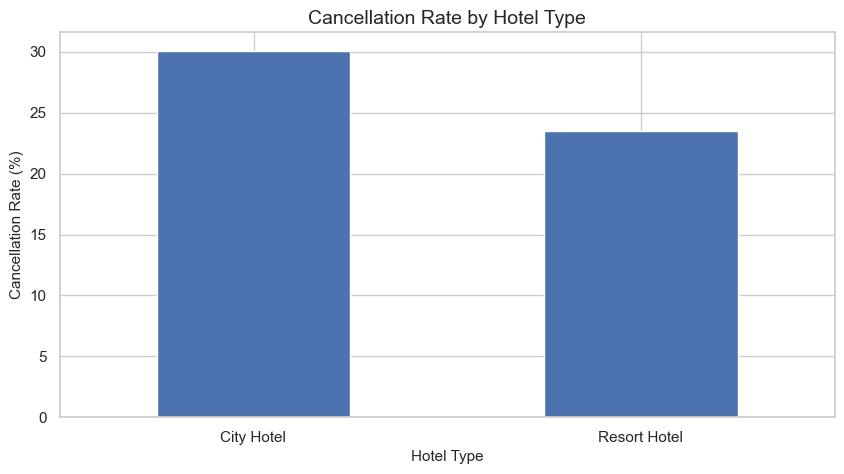

In [36]:
# Chart 1: cancellation rate by hotel type
cancel_by_hotel = (
    df_final_cleaned.groupby('hotel')['is_canceled']
    .apply(lambda x: x.astype(int).mean())
    .sort_values(ascending=False) * 100
)

ax = cancel_by_hotel.plot(kind='bar')
ax.set_title('Cancellation Rate by Hotel Type')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xlabel('Hotel Type')
plt.xticks(rotation=0)
plt.show()


In [37]:
df_final_cleaned.columns

Index(['hotel', 'is_canceled', 'lead_time', 'adults', 'children', 'babies',
       'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'required_car_parking_spaces',
       'total_of_special_requests', 'lead_time_capped', 'arrival_date_YMD',
       'arrival_month_num', 'total_nights', 'total_guests', 'is_family',
       'revenue_proxy', 'different_room_assigned', 'adr_capped'],
      dtype='object')

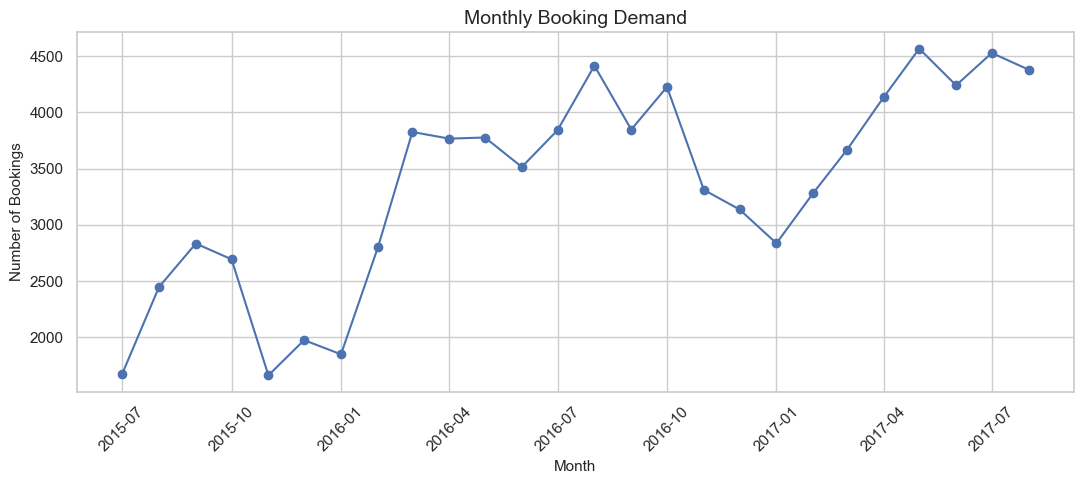

In [38]:
# Chart 2: monthly booking demand
# make sure the date column is datetime
df_final_cleaned['arrival_date_YMD'] = pd.to_datetime(df_final_cleaned['arrival_date_YMD'])

# monthly booking demand
monthly_bookings = (
    df_final_cleaned.groupby(pd.Grouper(key='arrival_date_YMD', freq='MS'))
    .size()
    .rename('bookings')
    .reset_index()
)

plt.figure(figsize=(11, 5))
plt.plot(monthly_bookings['arrival_date_YMD'], monthly_bookings['bookings'], marker='o')
plt.title('Monthly Booking Demand')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


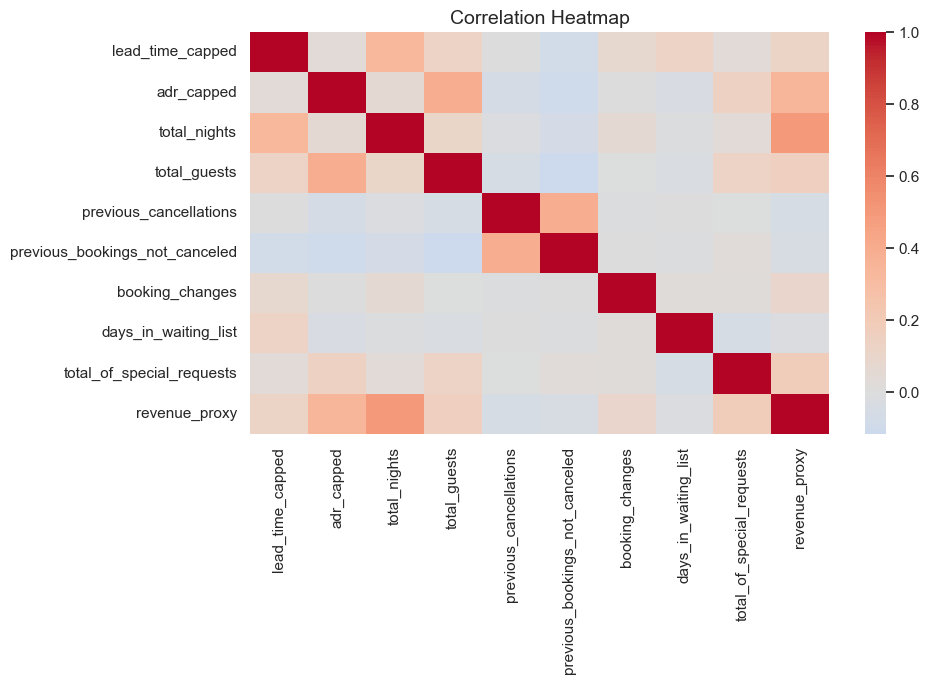

In [39]:
# Chart 3: correlation heatmap for selected numeric features
numeric_cols = [
    'lead_time_capped','adr_capped','total_nights','total_guests',
    'previous_cancellations','previous_bookings_not_canceled',
    'booking_changes','days_in_waiting_list','total_of_special_requests',
    'revenue_proxy','is_canceled'
]

corr = df_final_cleaned[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_correlation_heatmap.png', dpi=200)
plt.show()


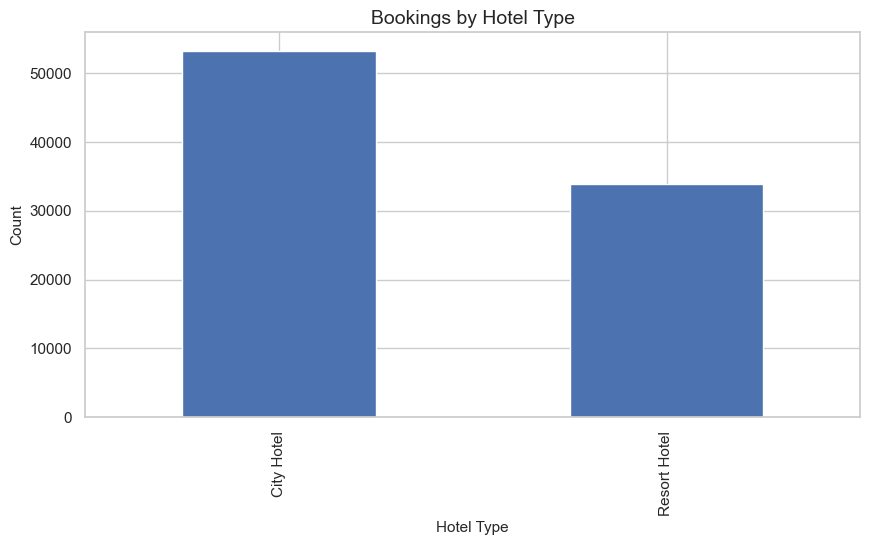

In [40]:
df_clean['hotel'].value_counts().plot(kind='bar')
plt.title('Bookings by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Count')
plt.show()

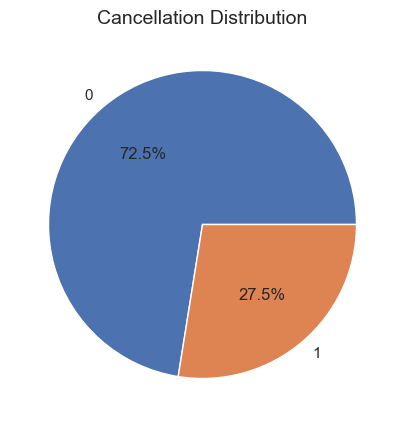

In [41]:
df_clean['is_canceled'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Cancellation Distribution')
plt.ylabel('')
plt.show()

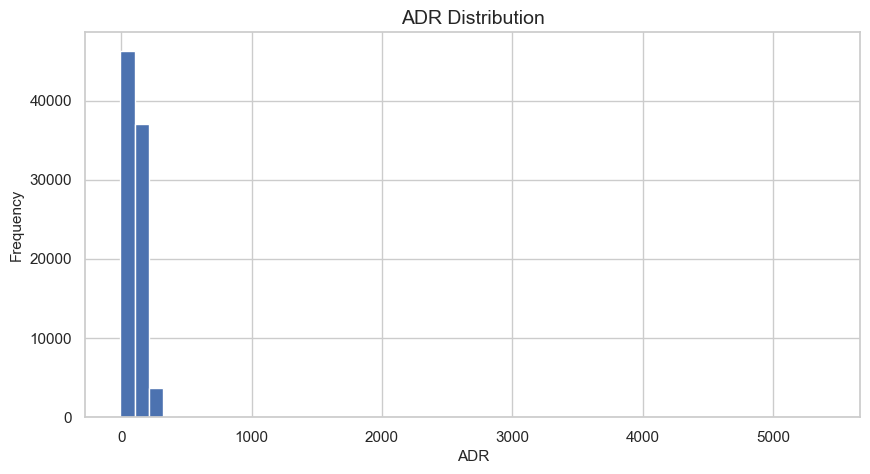

In [42]:
plt.hist(df_clean['adr'], bins=50)
plt.title('ADR Distribution')
plt.xlabel('ADR')
plt.ylabel('Frequency')
plt.show()

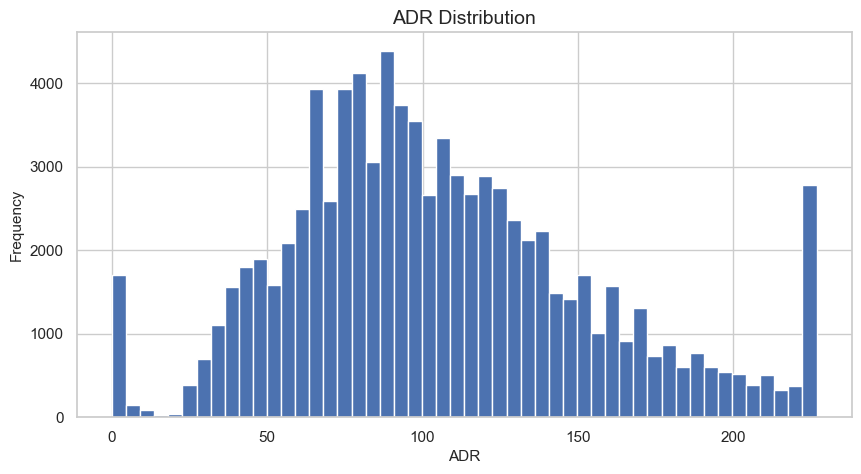

In [43]:
plt.hist(df_clean['adr_capped'], bins=50)
plt.title('ADR Distribution')
plt.xlabel('ADR')
plt.ylabel('Frequency')
plt.show()

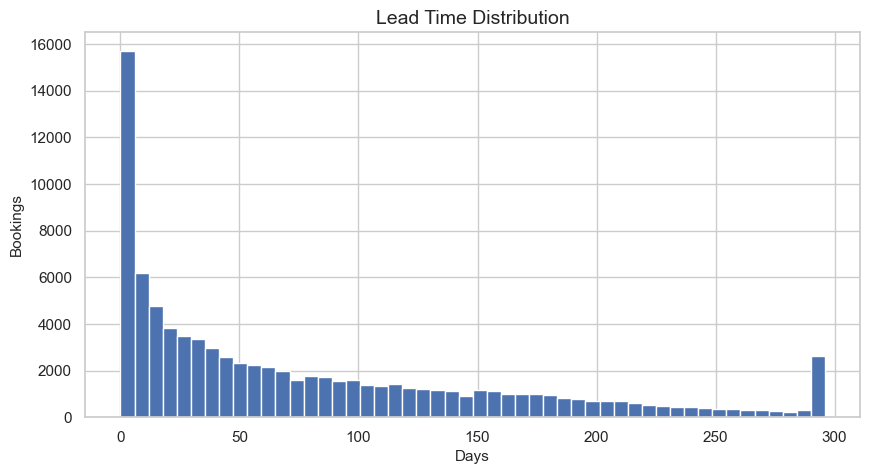

In [44]:
plt.hist(df_clean['lead_time_capped'], bins=50)
plt.title('Lead Time Distribution')
plt.xlabel('Days')
plt.ylabel('Bookings')
plt.show()

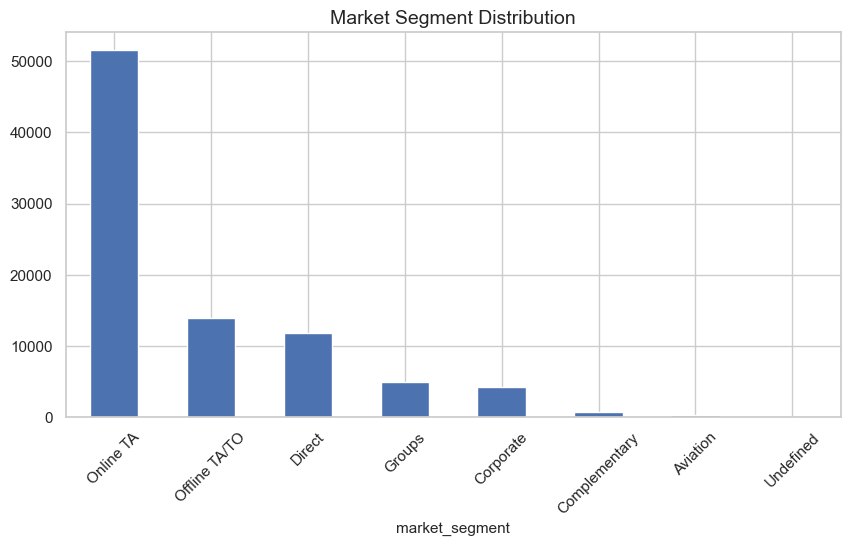

In [45]:
df_clean['market_segment'].value_counts().plot(kind='bar')
plt.title('Market Segment Distribution')
plt.xticks(rotation=45)
plt.show()

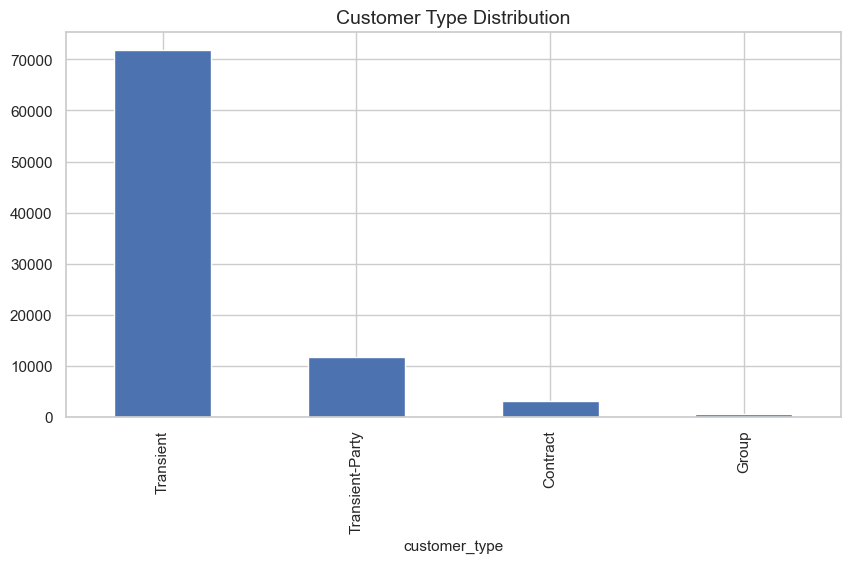

In [46]:
df_clean['customer_type'].value_counts().plot(kind='bar')
plt.title('Customer Type Distribution')
plt.show()

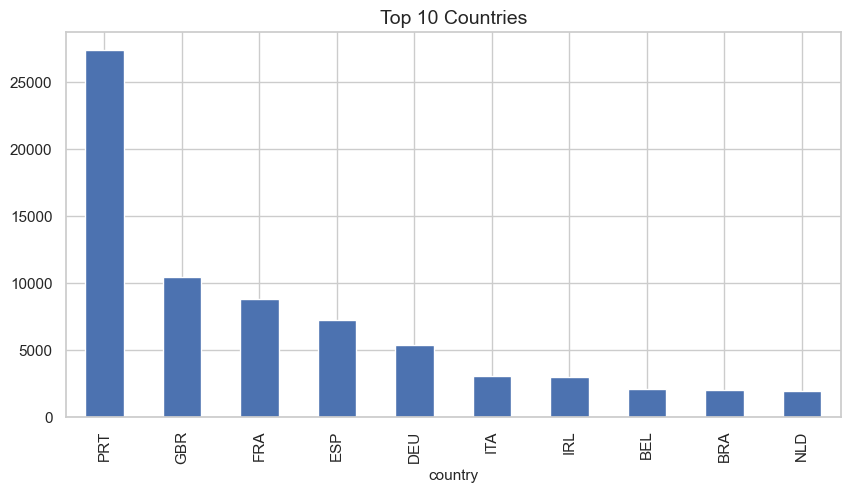

In [47]:
df_clean['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries')
plt.show()

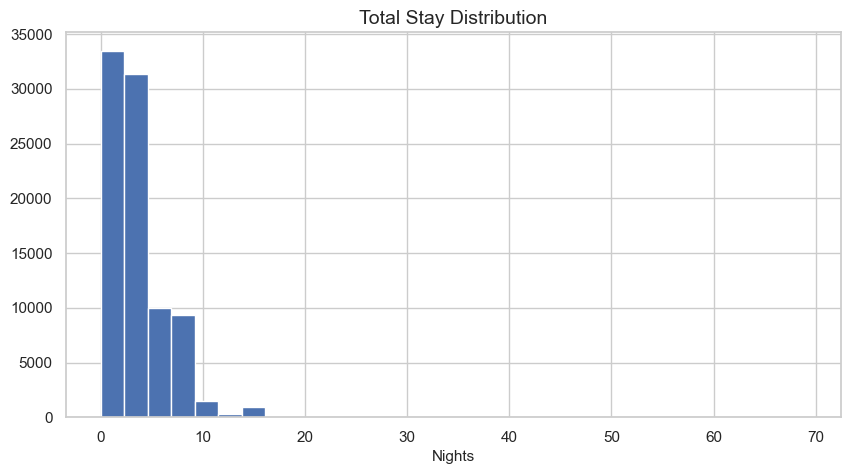

In [48]:
df_clean['total_stay'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']

plt.hist(df_clean['total_stay'], bins=30)
plt.title('Total Stay Distribution')
plt.xlabel('Nights')
plt.show()

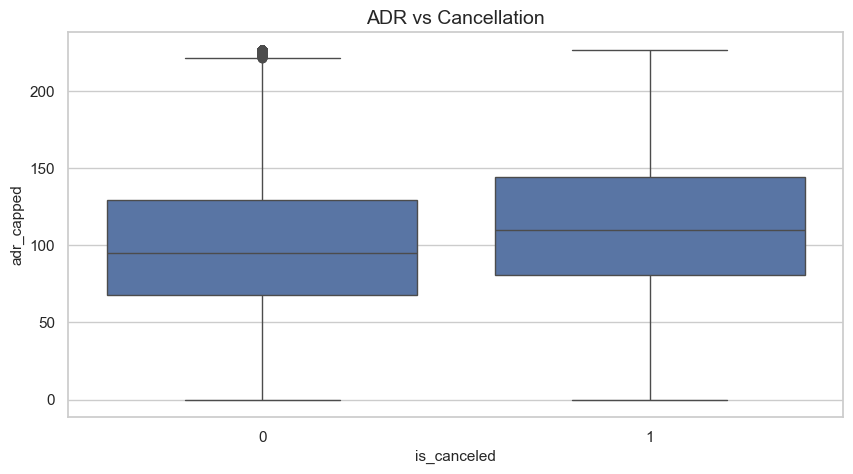

In [49]:
import seaborn as sns
sns.boxplot(x='is_canceled', y='adr_capped', data=df_clean)
plt.title('ADR vs Cancellation')
plt.show()

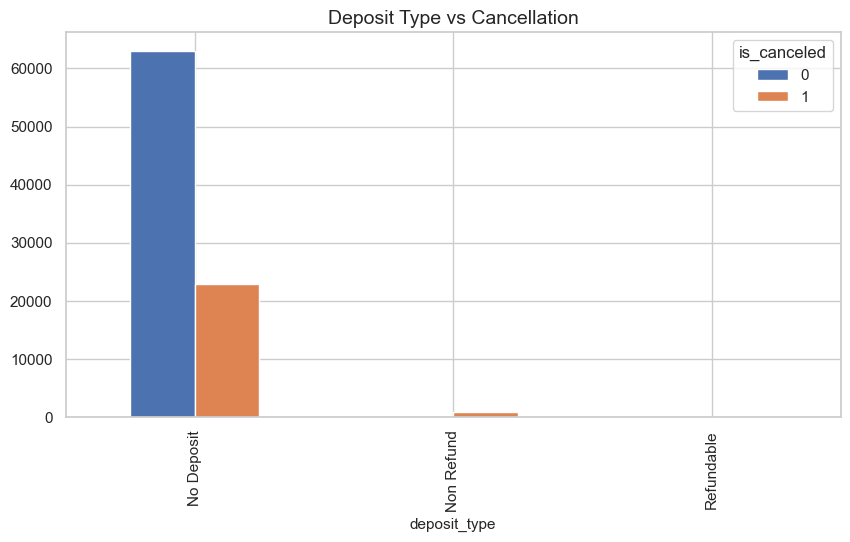

In [50]:
pd.crosstab(df_clean['deposit_type'], df_clean['is_canceled']).plot(kind='bar')
plt.title('Deposit Type vs Cancellation')
plt.show()

## 4. Clustering

In [93]:
df_final_cleaned.columns

Index(['hotel', 'is_canceled', 'lead_time', 'adults', 'children', 'babies',
       'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'required_car_parking_spaces',
       'total_of_special_requests', 'lead_time_capped', 'arrival_date_YMD',
       'arrival_month_num', 'total_nights', 'total_guests', 'is_family',
       'revenue_proxy', 'different_room_assigned', 'adr_capped'],
      dtype='object')

In [94]:
cluster_features = [
    'lead_time_capped', 'adr_capped', 'total_nights', 'total_guests',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'booking_changes', 'days_in_waiting_list',
    'required_car_parking_spaces', 'total_of_special_requests',
    'is_repeated_guest', 'is_family',
]

In [95]:
cluster_df = df_clean[cluster_features].dropna().copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

In [ ]:
scores = []
ks = range(2, 7)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

best_k = list(ks)[int(np.argmax(scores))]
print('Best k based on silhouette score:', best_k)

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(list(ks), scores, marker='o')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_silhouette_scores.png', dpi=200)
plt.show()


In [ ]:

# Final KMeans model
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
cluster_df['cluster'] = cluster_labels

# Attach cluster label back to cleaned dataframe using aligned index
clustered_data = df_clean.loc[cluster_df.index].copy()
clustered_data['cluster'] = cluster_labels

cluster_profile = clustered_data.groupby('cluster')[cluster_features].mean().round(2)
display(cluster_profile)


In [ ]:

# 2D cluster visualization using PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame(coords, columns=['PC1', 'PC2'])
plot_df['cluster'] = cluster_labels.astype(str)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster', palette='tab10', alpha=0.7)
plt.title('Customer / Booking Segments (PCA Projection)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_cluster_pca.png', dpi=200)
plt.show()


## 5. Forecasting monthly demand - Linear Regression

### Linear Regression

In [52]:
df_final_cleaned['arrival_date_YMD'] = pd.to_datetime(df_final_cleaned['arrival_date_YMD'])

In [53]:
monthly_data = (
    df_final_cleaned
    .groupby(pd.Grouper(key='arrival_date_YMD', freq='MS'))
    .size()
    .rename('bookings')
    .reset_index()
)

display(monthly_data.head())

,arrival_date_YMD,bookings
0,2015-07-01,1672
1,2015-08-01,2447
2,2015-09-01,2834
3,2015-10-01,2694
4,2015-11-01,1662


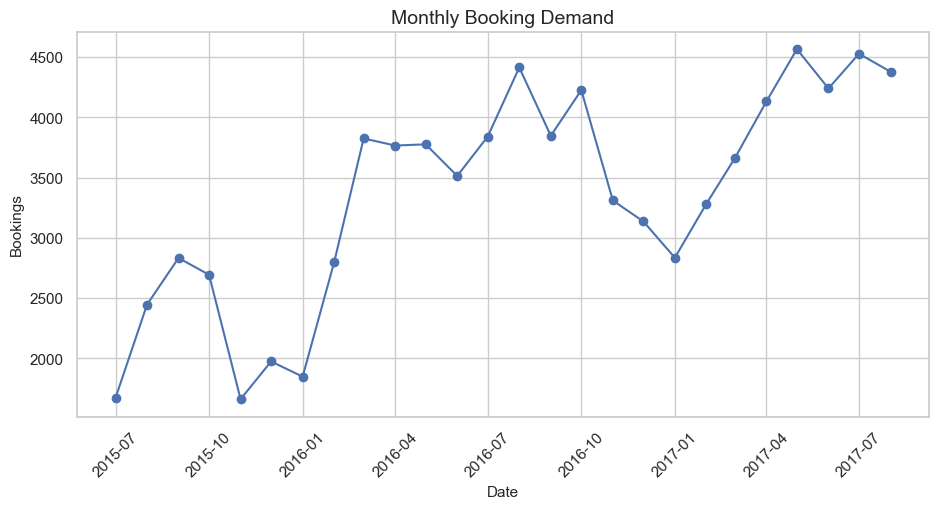

In [54]:
plt.figure(figsize=(11,5))
plt.plot(monthly_data['arrival_date_YMD'], monthly_data['bookings'], marker='o')
plt.title('Monthly Booking Demand')
plt.xlabel('Date')
plt.ylabel('Bookings')
plt.xticks(rotation=45)
plt.show()

In [55]:
monthly_data['time_index'] = np.arange(len(monthly_data))

In [56]:
X = monthly_data[['time_index']]
y = monthly_data['bookings']

model = LinearRegression()
model.fit(X, y)

monthly_data['predicted'] = model.predict(X)

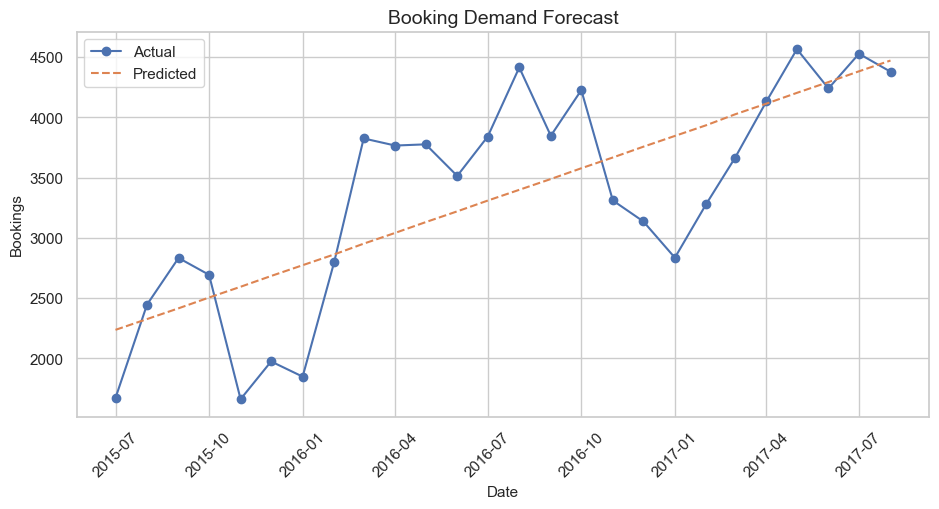

In [57]:
plt.figure(figsize=(11,5))
plt.plot(monthly_data['arrival_date_YMD'], monthly_data['bookings'], label='Actual', marker='o')
plt.plot(monthly_data['arrival_date_YMD'], monthly_data['predicted'], label='Predicted', linestyle='--')

plt.title('Booking Demand Forecast')
plt.xlabel('Date')
plt.ylabel('Bookings')
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [58]:
mae = mean_absolute_error(y, monthly_data['predicted'])
rmse = np.sqrt(mean_squared_error(y, monthly_data['predicted']))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 488.09
RMSE: 578.02


In [59]:
future_periods = 6  # next 6 months

future_index = np.arange(len(monthly_data), len(monthly_data) + future_periods)
future_predictions = model.predict(future_index.reshape(-1, 1))

future_dates = pd.date_range(
    start=monthly_data['arrival_date_YMD'].max(),
    periods=future_periods + 1,
    freq='MS'
)[1:]

future_df = pd.DataFrame({
    'arrival_date_YMD': future_dates,
    'forecasted_bookings': future_predictions
})

display(future_df)

,arrival_date_YMD,forecasted_bookings
0,2017-09-01,4562.098462
1,2017-10-01,4651.513162
2,2017-11-01,4740.927863
3,2017-12-01,4830.342564
4,2018-01-01,4919.757265
5,2018-02-01,5009.171966


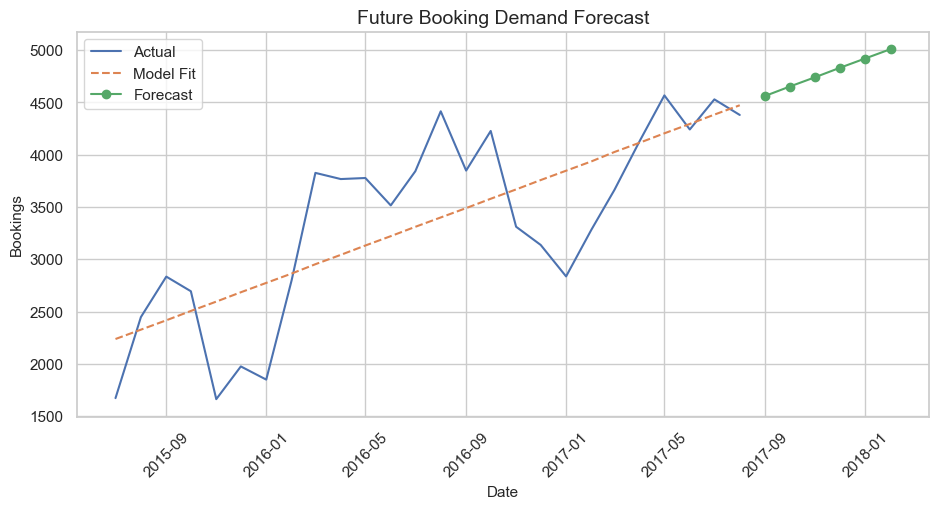

In [60]:
plt.figure(figsize=(11,5))

plt.plot(monthly_data['arrival_date_YMD'], monthly_data['bookings'], label='Actual')
plt.plot(monthly_data['arrival_date_YMD'], monthly_data['predicted'], label='Model Fit', linestyle='--')
plt.plot(future_df['arrival_date_YMD'], future_df['forecasted_bookings'], label='Forecast', marker='o')

plt.title('Future Booking Demand Forecast')
plt.xlabel('Date')
plt.ylabel('Bookings')
plt.legend()
plt.xticks(rotation=45)
plt.show()

### ARIMA Model

In [62]:
from statsmodels.tsa.arima.model import ARIMA

In [63]:
# Ensure datetime
df_final_cleaned['arrival_date_YMD'] = pd.to_datetime(df_final_cleaned['arrival_date_YMD'])

# Monthly aggregation
ts = (
    df_final_cleaned
    .groupby(pd.Grouper(key='arrival_date_YMD', freq='MS'))
    .size()
    .rename('bookings')
)

# Convert to time series
ts = ts.asfreq('MS')  # ensures monthly frequency
ts = ts.fillna(0)

print(ts.head())

arrival_date_YMD
2015-07-01    1672
2015-08-01    2447
2015-09-01    2834
2015-10-01    2694
2015-11-01    1662
Freq: MS, Name: bookings, dtype: int64


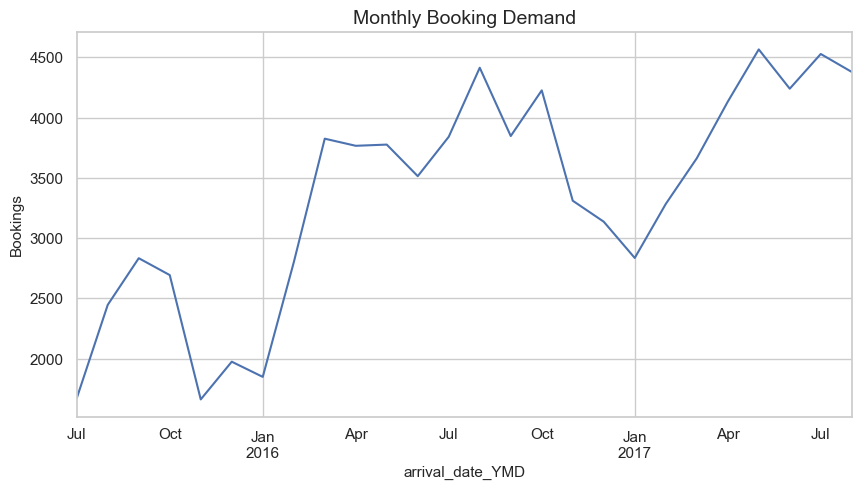

In [64]:
plt.figure(figsize=(10,5))
ts.plot()
plt.title('Monthly Booking Demand')
plt.ylabel('Bookings')
plt.show()

In [92]:
model = ARIMA(ts, order=(2,1,2))  # (p,d,q)
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               bookings   No. Observations:                   26
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -188.562
Date:                Sat, 11 Apr 2026   AIC                            387.124
Time:                        19:14:03   BIC                            393.219
Sample:                    07-01-2015   HQIC                           388.815
                         - 08-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8664      0.222      3.897      0.000       0.431       1.302
ar.L2         -0.8539      0.184     -4.643      0.000      -1.214      -0.493
ma.L1         -0.6318      0.303     -2.084      0.0

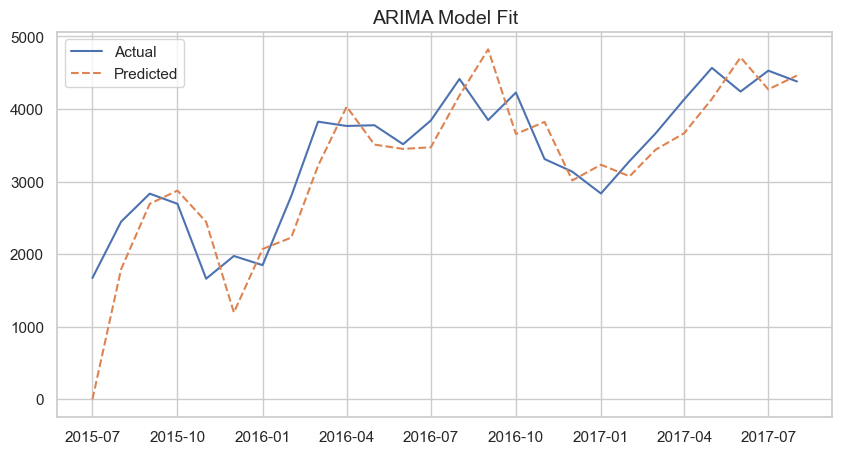

In [86]:
ts_pred = model_fit.predict(start=0, end=len(ts)-1)

plt.figure(figsize=(10,5))
plt.plot(ts.index, ts, label='Actual')
plt.plot(ts.index, ts_pred, label='Predicted', linestyle='--')
plt.legend()
plt.title('ARIMA Model Fit')
plt.show()

In [87]:
forecast_steps = 6  # next 6 months

forecast = model_fit.forecast(steps=forecast_steps)

print(forecast)

2017-09-01    4295.475681
2017-10-01    4272.874998
2017-11-01    4325.469052
2017-12-01    4390.336061
2018-01-01    4401.627495
2018-02-01    4356.020395
Freq: MS, Name: predicted_mean, dtype: float64


In [88]:
future_dates = pd.date_range(
    start=ts.index[-1],
    periods=forecast_steps + 1,
    freq='MS'
)[1:]

forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecasted_bookings': forecast.values
})

display(forecast_df)

,date,forecasted_bookings
0,2017-09-01,4295.475681
1,2017-10-01,4272.874998
2,2017-11-01,4325.469052
3,2017-12-01,4390.336061
4,2018-01-01,4401.627495
5,2018-02-01,4356.020395


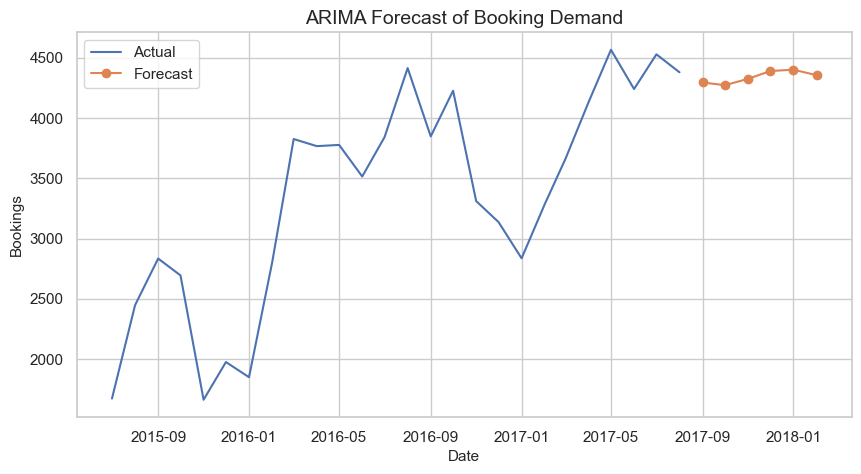

In [89]:
plt.figure(figsize=(10,5))

plt.plot(ts.index, ts, label='Actual')
plt.plot(forecast_df['date'], forecast_df['forecasted_bookings'],
         label='Forecast', marker='o')

plt.legend()
plt.title('ARIMA Forecast of Booking Demand')
plt.xlabel('Date')
plt.ylabel('Bookings')
plt.show()

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Align lengths
ts_pred = ts_pred[:len(ts)]

mae = mean_absolute_error(ts, ts_pred)
rmse = np.sqrt(mean_squared_error(ts, ts_pred))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 443.08
RMSE: 557.34
